In [52]:
import serial
import time
import struct

In [60]:

# Configure the serial connection
serial_port = '/dev/ttyACM0'  # Replace with your microcontroller's serial port
baud_rate = 1500000    # Replace with your microcontroller's baud rate
# Open the serial connection
ser = serial.Serial(serial_port,baudrate=baud_rate, timeout=0.01)
print(f"Connected to {serial_port} at {baud_rate} baud.")
# response = ser.readline()
# print(f"Response: {response.decode().strip()}")


Connected to /dev/ttyACM0 at 1500000 baud.


In [602]:

try:
    ser.flushInput()  # Clear the input buffer
    ser.flushOutput()  # Clear the output buffer
    OpMenuByte = 0x33
    value = 1
    # command = struct.pack('>BBBBH', OpMenuByte,0x01,0x01,0x01,int(value))
    command = struct.pack('>BBBBH', OpMenuByte,0x00,0x01,0x01,int(value))
    # Test sending and receiving commands
    # command = "TEST_CMD"  # Replace with the command you want to send
    start_time = time.time()
    
    # Send the command
    ser.write(command)
    print(f"Sent: {command}")
    
    # Wait for a response
    response = ser.readline()

    # ser.write(command)
    # print(f"Sent: {command}")data[len] = '\0';

    end_time = time.time()
    
    if response:
        print(f"Received: {response}")
    else:
        print("No response received.")
    
    # Calculate and display the round-trip time
    round_trip_time = end_time - start_time
    print(f"Round-trip time: {round_trip_time:.4f} seconds")



except serial.SerialException as e:
    print(f"Error: {e}")
    

# finally:
#     # Close the serial connection
#     if 'ser' in locals() and ser.is_open:
#         ser.close()
#         print("Serial connection closed.")

Sent: b'3\x00\x01\x01\x00\x01'
Received: b'3\x00\x01\x01\x00\x00\n'
Round-trip time: 0.0004 seconds


### Response time for digital read

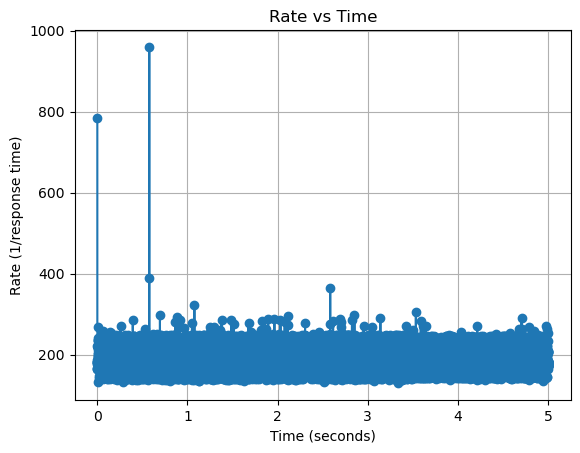

In [608]:
import matplotlib.pyplot as plt
command = struct.pack('>BBBBH', OpMenuByte,0x00,0x00,0x02,0x0001)
# Record rates and time
rates = []
timestamps = []
start_time = time.time()
response_time = []

while time.time() - start_time < 5:  # Run for 5 seconds
    try:
        
        ser.flushInput()  # Clear the input buffer
        ser.flushOutput()  # Clear the output buffer
        response_start = time.time()
        # Send the command
        ser.write(command)
        
        # Wait for a response
        
        response = ser.read(7)
        response_end = time.time()
        
        if response:
            response_ = (response_end - response_start)*1000000 # Convert to microseconds
            # rate = 1 / response_time if response_time > 0 else 0  # Avoid division by zero
            # if rate <2000:

            response_time.append(response_)  # Record the rate
            timestamps.append(time.time() - start_time)  # Record the elapsed time
    except serial.SerialException as e:
        print(f"Error: {e}")
        break

# Plot the graph
plt.plot(timestamps, response_time, marker='o')
plt.xlabel('Time (seconds)')
plt.ylabel('Rate (1/response time)')
plt.title('Rate vs Time')
plt.grid()
plt.show()


In [609]:
sum(response_time) / len(response_time)

184.98877719109723

In [612]:
1/185*1000000*13*8


562162.1621621622

### Response time for analog read

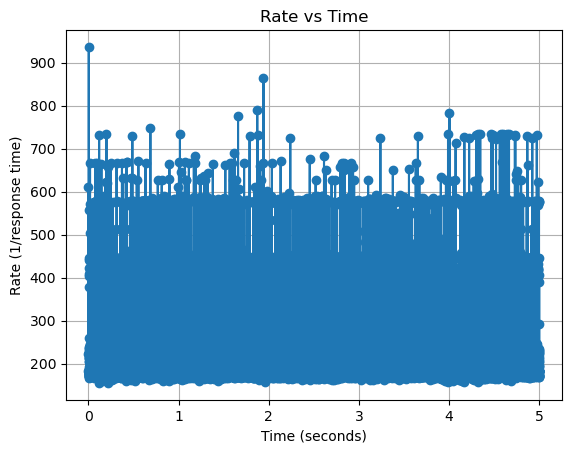

In [613]:
import matplotlib.pyplot as plt
command = struct.pack('>BBBBH', OpMenuByte,0x01,0x00,0x02,0x0001)
# Record rates and time
rates = []
timestamps = []
start_time = time.time()
response_time = []

while time.time() - start_time < 5:  # Run for 5 seconds
    try:
        
        ser.flushInput()  # Clear the input buffer
        ser.flushOutput()  # Clear the output buffer
        response_start = time.time()
        # Send the command
        ser.write(command)
        
        # Wait for a response
        
        response = ser.read(7)
        response_end = time.time()
        
        if response:
            response_ = (response_end - response_start)*1000000 # Convert to microseconds
            # rate = 1 / response_time if response_time > 0 else 0  # Avoid division by zero
            # if rate <2000:

            response_time.append(response_)  # Record the rate
            timestamps.append(time.time() - start_time)  # Record the elapsed time
    except serial.SerialException as e:
        print(f"Error: {e}")
        break

# Plot the graph
plt.plot(timestamps, response_time, marker='o')
plt.xlabel('Time (seconds)')
plt.ylabel('Rate (1/response time)')
plt.title('Rate vs Time')
plt.grid()
plt.show()


In [614]:
sum(response_time) / len(response_time)

222.65899443946205

### Response time for analog write

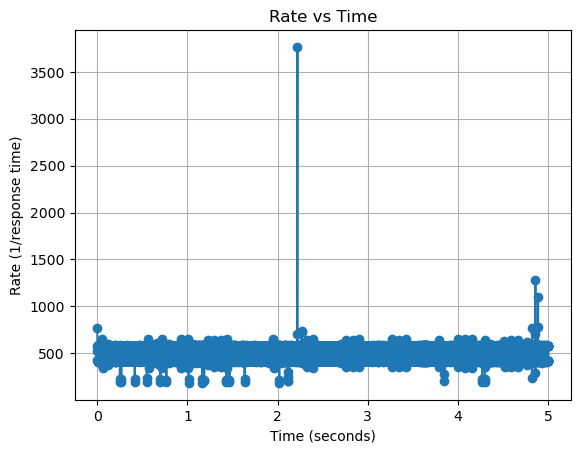

In [615]:
import matplotlib.pyplot as plt
command = struct.pack('>BBBBH', OpMenuByte,0x01,0x01,0x02,0xFF00)
# Record rates and time
# Record rates and time
rates = []
timestamps = []
start_time = time.time()
response_time = []

while time.time() - start_time < 5:  # Run for 5 seconds
    try:
        
        ser.flushInput()  # Clear the input buffer
        ser.flushOutput()  # Clear the output buffer
        response_start = time.time()
        # Send the command
        ser.write(command)
        
        # Wait for a response
        
        response = ser.read(7)
        response_end = time.time()
        
        if response:
            response_ = (response_end - response_start)*1000000 # Convert to microseconds
            # rate = 1 / response_time if response_time > 0 else 0  # Avoid division by zero
            # if rate <2000:

            response_time.append(response_)  # Record the rate
            timestamps.append(time.time() - start_time)  # Record the elapsed time
    except serial.SerialException as e:
        print(f"Error: {e}")
        break

# Plot the graph
plt.plot(timestamps, response_time, marker='o')
plt.xlabel('Time (seconds)')
plt.ylabel('Rate (1/response time)')
plt.title('Rate vs Time')
plt.grid()
plt.show()


In [616]:
sum(response_time) / len(response_time) 

497.9979807230784

### Response time for digital write

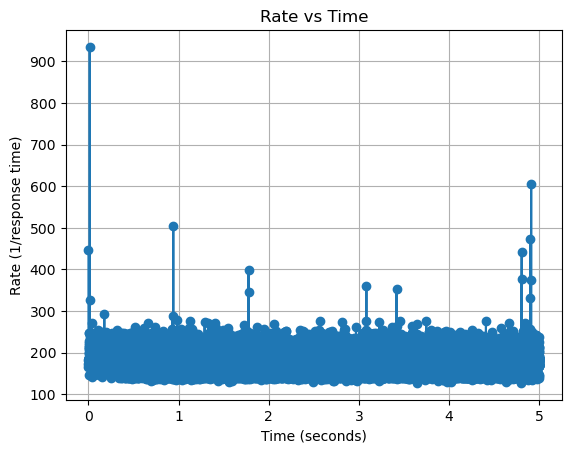

In [617]:
import matplotlib.pyplot as plt
command = struct.pack('>BBBBH', OpMenuByte,0x00,0x01,0x02,0x0001)
# Record rates and time
# Record rates and time
rates = []
timestamps = []
start_time = time.time()
response_time = []

while time.time() - start_time < 5:  # Run for 5 seconds
    try:
        
        ser.flushInput()  # Clear the input buffer
        ser.flushOutput()  # Clear the output buffer
        response_start = time.time()
        # Send the command
        ser.write(command)
        
        # Wait for a response
        
        response = ser.read(7)
        response_end = time.time()
        
        if response:
            response_ = (response_end - response_start)*1000000 # Convert to microseconds
            # rate = 1 / response_time if response_time > 0 else 0  # Avoid division by zero
            # if rate <2000:

            response_time.append(response_)  # Record the rate
            timestamps.append(time.time() - start_time)  # Record the elapsed time
    except serial.SerialException as e:
        print(f"Error: {e}")
        break

# Plot the graph
plt.plot(timestamps, response_time, marker='o')
plt.xlabel('Time (seconds)')
plt.ylabel('Rate (1/response time)')
plt.title('Rate vs Time')
plt.grid()
plt.show()


In [618]:
sum(response_time) / len(response_time) 

182.07025184653767